# Chapter 4 — Spontaneous Adoption Model
**Modeling Social Behavior** | Smaldino

---

### What this notebook does

We build a Python/Mesa version of the **Spontaneous Adoption** model from Section 4.2.  
In this model:
- Agents move around a 2-D toroidal space using a correlated random walk
- At every time step, each **susceptible** agent independently has a fixed probability α of spontaneously becoming **infected**. No contact with anyone else is required
- Once infected, an agent stays infected (no recovery)
- The simulation stops when everyone is infected

We also derive the **analytical solution** (the difference equation, Eq. 4.1) and overlay it on the simulation results to verify they match.


---
## 1. Imports and Setup


In [1]:
# Standard scientific stack
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Mesa is the standard Python library for agent-based modeling.
# It provides the Agent and Model base classes, a ContinuousSpace for
# placing agents in 2-D, and a DataCollector for recording variables over time.
#
# NOTE: This notebook uses Mesa 3.x, which has a modernized API compared
# to older versions. Key differences from Mesa 2.x:
#   - Agents register with the model automatically via super().__init__(model)
#   - No separate Scheduler class: use model.agents.do("step") to activate all agents
#   - Agents have a unique_id assigned automatically by the model
from mesa import Agent, Model
from mesa.space import ContinuousSpace
from mesa.datacollection import DataCollector

# Set a global random seed so results are reproducible
np.random.seed(42)

print("All imports successful.")


All imports successful.


---
## 2. The Agent Class

Each agent represents one individual in the population.  
Agents have two responsibilities each time step:
1. **Try to become infected** (if still susceptible)
2. **Move** using a correlated random walk

### Variable types in this class
| Variable | Type | Description |
|---|---|---|
| `self.infected` | Agent-level | Whether this agent has adopted / been infected |
| `self.heading` | Agent-level | Current direction of movement (radians) |
| `self.pos` | Agent-level | Current (x, y) position — set by Mesa's ContinuousSpace |


In [2]:
class SpontaneousAgent(Agent):
    """
    A single agent in the Spontaneous Adoption model.

    Agent-level variables:
        infected  (bool)  -- True if this agent has adopted / been infected
        heading   (float) -- Current movement direction in radians (0 to 2π)
    """

    def __init__(self, model):
        # Call the parent Agent constructor.
        # In Mesa 3.x, we only pass the model — the unique_id is assigned
        # automatically by the model's internal counter.
        super().__init__(model)

        # AGENT VARIABLE: infection status
        # All agents start susceptible (False). A small number will be flipped
        # to infected during model setup (see ContagionModel.__init__).
        self.infected = False

        # AGENT VARIABLE: movement heading
        # Each agent starts pointing in a random direction (uniform over full circle).
        # This heading is nudged each step to produce a correlated random walk.
        self.heading = self.random.uniform(0, 2 * np.pi)

    # ------------------------------------------------------------------
    # step() is called once per time step when the model activates agents.
    # Order: try to become infected first, then move.
    # ------------------------------------------------------------------
    def step(self):
        self._try_spontaneous_infection()
        self._move()

    # ------------------------------------------------------------------
    # SPONTANEOUS INFECTION
    # ------------------------------------------------------------------
    def _try_spontaneous_infection(self):
        """
        If the agent is still susceptible, flip a probabilistic coin.
        With probability alpha (the spontaneous infection rate, a global
        parameter stored on the model), this agent becomes infected.

        This is the core mechanism of the spontaneous adoption model:
        no contact with anyone else is needed — each agent independently
        has a fixed chance of adopting at every step.

        Corresponds to the term α(N - I_t) in Equation 4.1 of the book.
        """
        if not self.infected:
            # Draw a uniform random number in [0, 1).
            # If it falls below alpha, the agent spontaneously adopts.
            if self.random.random() < self.model.alpha:
                self.infected = True

    # ------------------------------------------------------------------
    # CORRELATED RANDOM WALK
    # ------------------------------------------------------------------
    def _move(self):
        """
        Move the agent one step using a correlated random walk:
          1. Nudge the current heading by a random amount within ±(turning_angle/2)
          2. Take a step of length `speed` in the new direction
          3. Wrap around the toroidal boundary (Mesa handles this automatically)

        A small turning_angle → nearly straight-line motion (high correlation).
        A large turning_angle (360°) → nearly uncorrelated / Brownian motion.
        """
        # LOCAL VARIABLE: max_turn — half the turning angle, converted to radians
        max_turn = np.radians(self.model.turning_angle) / 2
        self.heading += self.random.uniform(-max_turn, max_turn)

        # LOCAL VARIABLES: dx, dy — displacement components for this step
        dx = self.model.speed * np.cos(self.heading)
        dy = self.model.speed * np.sin(self.heading)

        # Ask Mesa's ContinuousSpace to move us, respecting toroidal wrapping.
        # torus=True (set at model creation) means coordinates wrap automatically.
        new_x = self.pos[0] + dx
        new_y = self.pos[1] + dy
        self.model.space.move_agent(self, (new_x, new_y))


---
## 3. The Model Class

The model class is the "world" that holds all agents, the space, and the global parameters.

### Variable types in this class
| Variable | Type | Description |
|---|---|---|
| `N` | Global | Total number of agents |
| `init_infected` | Global | Number of agents infected at initialization |
| `alpha` | Global | Spontaneous infection rate (α in the book) |
| `speed` | Global | Distance each agent travels per step |
| `turning_angle` | Global | Maximum heading change per step (degrees) |
| `width`, `height` | Global | Dimensions of the 2-D space |


In [3]:
class ContagionModel(Model):
    """
    The Spontaneous Adoption (Contagion) model.

    Global parameters:
        N              (int)   -- total number of agents
        init_infected  (int)   -- number of initially infected agents (the 'seeds')
        alpha          (float) -- probability of spontaneous infection per step
        speed          (float) -- distance moved per step
        turning_angle  (float) -- max heading change per step, in degrees
        width, height  (float) -- size of the 2-D toroidal space
    """

    def __init__(
        self,
        N=1000,
        init_infected=1,
        alpha=0.01,
        speed=0.5,
        turning_angle=60,
        width=33,
        height=33,
    ):
        super().__init__()

        # ── GLOBAL VARIABLES ──────────────────────────────────────────
        self.N = N
        self.init_infected = init_infected
        self.alpha = alpha          # spontaneous infection rate (α)
        self.speed = speed
        self.turning_angle = turning_angle
        self.running = True         # Mesa convention: set False to stop the model

        # ── SPACE ─────────────────────────────────────────────────────
        # ContinuousSpace gives each agent a float (x, y) coordinate.
        # torus=True means agents that walk off one edge reappear on the other
        # (toroidal / wrap-around boundaries, as described in the book).
        self.space = ContinuousSpace(width, height, torus=True)

        # ── CREATE AGENTS ─────────────────────────────────────────────
        # In Mesa 3.x, creating an agent and calling super().__init__(model)
        # automatically registers it with the model — no separate scheduler needed.
        for _ in range(self.N):
            agent = SpontaneousAgent(self)
            # Place each agent at a random location in the space
            x = self.random.uniform(0, width)
            y = self.random.uniform(0, height)
            self.space.place_agent(agent, (x, y))

        # ── SEED INITIAL INFECTIONS ───────────────────────────────────
        # Select init_infected agents at random and mark them as infected.
        # These are the 'innovators' / index cases that start the spread.
        # We clamp init_infected in case someone sets it larger than N.
        n_seed = min(self.init_infected, self.N)
        # self.agents is a Mesa 3 AgentSet — we sample from it directly
        seeds = self.agents.select(lambda a: True)[:n_seed]
        for agent in seeds:
            agent.infected = True

        # ── DATA COLLECTOR ────────────────────────────────────────────
        # Mesa's DataCollector records model-level variables at every step.
        # Here we track the proportion of infected agents over time.
        self.datacollector = DataCollector(
            model_reporters={
                # The reporter is a callable that receives the model as its argument.
                # We compute: proportion_infected = (number infected) / N
                "proportion_infected": lambda m: sum(
                    1 for a in m.agents if a.infected
                ) / m.N
            }
        )

        # Collect data at time step 0 (initial state) before any dynamics run
        self.datacollector.collect(self)

    def step(self):
        """
        Advance the model by one time step:
        1. Activate all agents in random order — each agent tries to become
           infected and then moves.
        2. Collect data for this time step.
        3. Stop if everyone is infected.
        """
        # model.agents.shuffle_do("step") activates every agent's step() method
        # in a randomly shuffled order, preventing systematic ordering bias.
        self.agents.shuffle_do("step")

        # Record the current state
        self.datacollector.collect(self)

        # Stop condition: simulation ends when no susceptible agents remain
        n_infected = sum(1 for a in self.agents if a.infected)
        if n_infected == self.N:
            self.running = False

    def run(self, max_steps=2000):
        """
        Run the model for up to max_steps steps, or until everyone is infected.
        Returns the recorded data as a pandas DataFrame.
        """
        for _ in range(max_steps):
            if not self.running:
                break
            self.step()
        return self.datacollector.get_model_vars_dataframe()


---
## 4. The Analytical Solution (Difference Equation)

Before running the simulation, let's compute the **analytical prediction** using the difference equation from the book (Equation 4.1):

$$I_{t+1} = I_t + \alpha (N - I_t)$$

This tells us exactly how many infected agents we *expect* at each time step, given perfect well-mixed conditions with no randomness.  
We then compare this smooth theoretical curve to the noisy simulation output.

### Variables used here
| Variable | Type | Description |
|---|---|---|
| `N` | Local (parameter) | Total population size |
| `alpha` | Local (parameter) | Spontaneous infection rate |
| `I0` | Local (parameter) | Initial number of infected agents |
| `n_steps` | Local (parameter) | Number of time steps to compute |
| `I` | Local | List accumulating I_t values over time |
| `proportion` | Local | I values divided by N (for plotting) |


In [4]:
def analytical_spontaneous(N, alpha, I0, n_steps):
    """
    Numerically solves the difference equation for spontaneous adoption:

        I_{t+1} = I_t + alpha * (N - I_t)        [Equation 4.1]

    Parameters
    ----------
    N        : int   -- total population size
    alpha    : float -- spontaneous infection rate per step
    I0       : int   -- initial number of infected agents
    n_steps  : int   -- number of time steps to compute

    Returns
    -------
    proportion : np.ndarray
        Array of length n_steps+1 giving the proportion infected at each
        time step (I_t / N).
    """
    # LOCAL VARIABLE: I — list of infected counts, one per time step.
    # We start from I0 (the seed infections at t=0).
    I = [I0]

    for t in range(n_steps):
        # LOCAL VARIABLE: I_current — the infected count at the current step
        I_current = I[-1]

        # New infections this step = alpha × (susceptibles remaining)
        # Susceptibles = N - I_current
        new_infections = alpha * (N - I_current)

        # Recursion: next step's count = current + new infections
        I_next = I_current + new_infections
        I.append(I_next)

    # Convert raw counts to proportions for easy comparison with simulation
    proportion = np.array(I) / N
    return proportion


# ── Quick sanity check ────────────────────────────────────────────────────────
analytical_curve = analytical_spontaneous(N=1000, alpha=0.01, I0=1, n_steps=700)

print(f"Analytical curve (N=1000, α=0.01) — proportion infected:")
print(f"  t=0:    {analytical_curve[0]:.4f}")
print(f"  t=300:  {analytical_curve[300]:.4f}")
print(f"  t=700:  {analytical_curve[700]:.4f}  (should approach 1.0)")


Analytical curve (N=1000, α=0.01) — proportion infected:
  t=0:    0.0010
  t=300:  0.9510
  t=700:  0.9991  (should approach 1.0)


---
## 5. Run the Agent-Based Simulation

We now run the model and compare the simulation output to the analytical prediction.

**Parameters** (matching the book's defaults):
| Parameter | Value | Notes |
|---|---|---|
| N | 1000 | Population size |
| init_infected | 1 | One seed infection |
| alpha (α) | 0.01 | 1% chance of spontaneous adoption per step |
| speed | 0.5 | Distance per step |
| turning_angle | 60° | Moderate correlation in movement |


In [5]:
# ── GLOBAL PARAMETERS ────────────────────────────────────────────────────────
# These match the book's default settings for the spontaneous adoption model.
N             = 1000   # total population
init_infected = 1      # number of seed infections at t=0
alpha         = 0.01   # spontaneous infection rate (α)
speed         = 0.5    # movement speed (distance per step)
turning_angle = 60     # max heading change per step (degrees)

# ── RUN THE MODEL ─────────────────────────────────────────────────────────────
print("Running agent-based simulation...")
model = ContagionModel(
    N=N,
    init_infected=init_infected,
    alpha=alpha,
    speed=speed,
    turning_angle=turning_angle,
)
sim_data = model.run(max_steps=2000)

# sim_data is a pandas DataFrame — index = time step, column = proportion_infected
n_steps_sim = len(sim_data) - 1
print(f"Simulation finished after {n_steps_sim} steps.")
print(f"Final proportion infected: {sim_data['proportion_infected'].iloc[-1]:.4f}")


Running agent-based simulation...
Simulation finished after 738 steps.
Final proportion infected: 1.0000


---
## 6. Plot: Simulation vs. Analytical Prediction

We overlay:
- **Red line** — the agent-based simulation output (proportion infected over time)
- **Grey line** — the analytical prediction from the difference equation (Eq. 4.1)

This replicates Figure 4.3 from the book. The two curves should match closely,  
confirming that the math correctly captures the model's behavior.


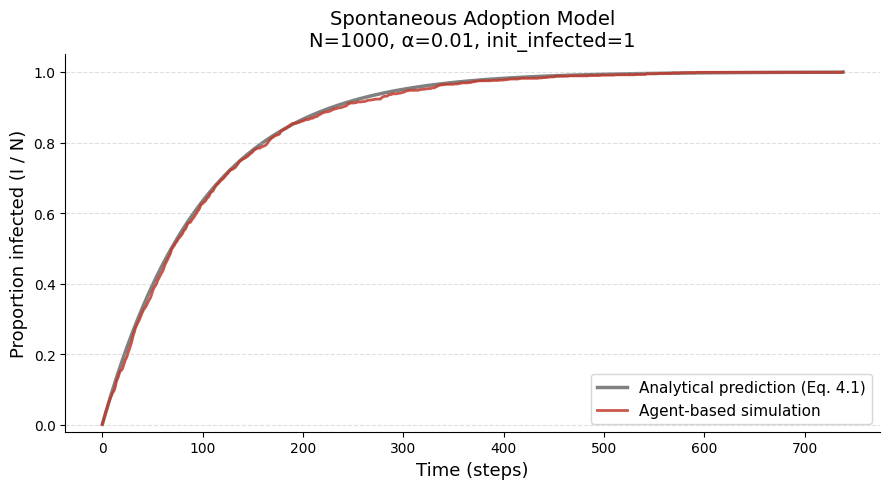

In [9]:
# ── COMPUTE ANALYTICAL CURVE ─────────────────────────────────────────────────
# Computed for the same number of steps the simulation ran,
# using the identical parameter values.
analytical = analytical_spontaneous(N, alpha, init_infected, n_steps_sim)

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# LOCAL VARIABLE: time_steps — x-axis array from 0 to n_steps_sim
time_steps = np.arange(n_steps_sim + 1)

# Analytical prediction (grey, drawn first so it sits behind the simulation)
ax.plot(
    time_steps,
    analytical,
    color="grey",
    linewidth=2.5,
    label="Analytical prediction (Eq. 4.1)",
    zorder=1,
)

# Simulation output (red, on top)
ax.plot(
    time_steps,
    sim_data["proportion_infected"].values,
    color="#c0392b",
    linewidth=2,
    alpha=0.85,
    label="Agent-based simulation",
    zorder=2,
)

# ── FORMATTING ────────────────────────────────────────────────────────────────
ax.set_xlabel("Time (steps)", fontsize=13)
ax.set_ylabel("Proportion infected (I / N)", fontsize=13)
ax.set_title(
    f"Spontaneous Adoption Model\n"
    f"N={N}, α={alpha}, init_infected={init_infected}",
    fontsize=14,
)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


---
## 7. Parameter Exploration: Effect of α (alpha)

How does the spontaneous infection rate α change the dynamics?  
We run the simulation for several values of α and overlay the results.

**What to look for:**
- Higher α → faster spread (the S-curve shifts left)
- The *shape* stays S-shaped regardless of α
- All curves eventually reach full adoption — α only controls speed, not the final outcome


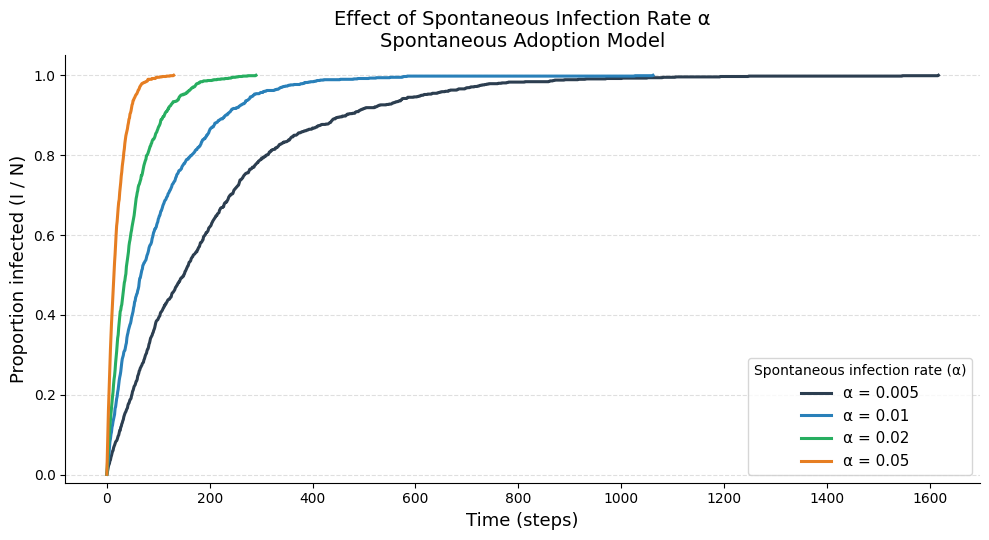

In [8]:
# GLOBAL VARIABLE: alpha_values — the set of α values to explore
alpha_values = [0.005, 0.01, 0.02, 0.05]

# Color palette for the four curves
colors = ["#2c3e50", "#2980b9", "#27ae60", "#e67e22"]

fig, ax = plt.subplots(figsize=(10, 5.5))

for alpha_val, color in zip(alpha_values, colors):
    # Run a fresh model for each value of alpha.
    # LOCAL VARIABLE: m — a single model run
    m = ContagionModel(
        N=N,
        init_infected=init_infected,
        alpha=alpha_val,
        speed=speed,
        turning_angle=turning_angle,
    )
    data = m.run(max_steps=3000)

    # LOCAL VARIABLE: steps — number of steps this particular run took
    steps = len(data) - 1
    t = np.arange(steps + 1)

    ax.plot(
        t,
        data["proportion_infected"].values,
        color=color,
        linewidth=2.2,
        label=f"α = {alpha_val}",
    )

ax.set_xlabel("Time (steps)", fontsize=13)
ax.set_ylabel("Proportion infected (I / N)", fontsize=13)
ax.set_title(
    "Effect of Spontaneous Infection Rate α\nSpontaneous Adoption Model",
    fontsize=14,
)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=11, title="Spontaneous infection rate (α)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


---
## 8. Reflection and Key Takeaways

### What the model showed us

1. **The S-curve emerges without social influence.**  
   Even though no agent ever talks to another, the cumulative adoption curve is S-shaped.  
   The slowdown at the end happens purely because the *pool of susceptibles shrinks* not because of any social dynamics.

2. **The analytical model matches the ABM closely.**  
   The grey curve (difference equation, Eq. 4.1) overlaps tightly with the red simulation curve.  
   This validates our Python implementation and confirms that the math captures the essential dynamics.

3. **α controls speed, not shape.**  
   Changing α shifts the S-curve left or right but preserves its fundamental shape.  
   All values of α eventually lead to full adoption. α only determines how fast.

### Limitations of this model

- **No social influence** — adoption is driven entirely by individual probability, not exposure to others. This is useful as a baseline but unrealistic as a true contagion model.
- **Identical agents** — every agent has the same α. Rogers' adopter taxonomy (innovators, early majority, laggards) would require different α values across agents.
- **No recovery** — once infected, always infected. The next models (SIS, SIR) will relax this.
